# 🤖 Model Training — NSL-KDD
Loads processed data from `data/processed/`, fits a StandardScaler (on training data only),
then trains Random Forest and XGBoost using **SMOTE inside a cross-validated pipeline**
— guaranteeing zero data leakage.

**Pipeline per model:**
```
ImbPipeline [ SMOTE → Classifier ]
    ↓
RandomizedSearchCV (3-Fold Stratified CV, 5 random configs, F1 Macro scoring)
    ↓
Holdout evaluation on test set
```

**Run order:** `prepare_data.ipynb` → this notebook


## Imports

In [4]:
import os
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, auc, classification_report, confusion_matrix,
    f1_score, precision_recall_fscore_support, roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

CLASS_LABELS = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']
COLORS       = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#e67e22']
MODELS_DIR   = os.path.join('..', 'models')
REPORTS_DIR  = os.path.join('..', 'reports')
DATA_DIR     = os.path.join("..",'data', 'processed')

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

## Step 1 — Load Processed Data

In [5]:
X_train = joblib.load(os.path.join(DATA_DIR, 'X_train.pkl'))
X_test  = joblib.load(os.path.join(DATA_DIR, 'X_test.pkl'))
y_train = joblib.load(os.path.join(DATA_DIR, 'y_train.pkl'))
y_test  = joblib.load(os.path.join(DATA_DIR, 'y_test.pkl'))

print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}  |  y_test  : {y_test.shape}")

X_train : (125973, 122)  |  X_test : (22544, 122)
y_train : (125973,)  |  y_test  : (22544,)


## Step 2 — Feature Scaling

`StandardScaler` is **fit only on the training set**, then applied to both.
This prevents test-set statistics from influencing the scaling (data leakage).


In [6]:
scaler      = StandardScaler()
X_train_sc  = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_sc   = pd.DataFrame(scaler.transform(X_test),      columns=X_train.columns)

joblib.dump(scaler,                os.path.join(MODELS_DIR, 'scaler.pkl'))
joblib.dump(list(X_train.columns), os.path.join(MODELS_DIR, 'model_columns.pkl'))
joblib.dump(X_test_sc.values, os.path.join(DATA_DIR, 'X_test_scaled_arr.pkl'))
print("Saved: scaler.pkl, model_columns.pkl")
X_train_sc.describe().round(2)

Saved: scaler.pkl, model_columns.pkl


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
count,125973.00,125973.00,125973.00,125973.00,125973.00,125973.00,125973.00,125973.00,125973.00,125973.00,...,125973.00,125973.00,125973.00,125973.00,125973.00,125973.00,125973.00,125973.00,125973.00,125973.00
mean,0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,...,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.11,-0.01,-0.00,-0.01,-0.09,-0.01,-0.10,-0.03,-0.81,-0.01,...,-0.31,-0.11,-0.03,-0.14,-0.62,-0.05,-0.03,-0.02,-1.21,-0.05
25%,-0.11,-0.01,-0.00,-0.01,-0.09,-0.01,-0.10,-0.03,-0.81,-0.01,...,-0.31,-0.11,-0.03,-0.14,-0.62,-0.05,-0.03,-0.02,-1.21,-0.05
50%,-0.11,-0.01,-0.00,-0.01,-0.09,-0.01,-0.10,-0.03,-0.81,-0.01,...,-0.31,-0.11,-0.03,-0.14,-0.62,-0.05,-0.03,-0.02,0.83,-0.05
75%,-0.11,-0.01,-0.00,-0.01,-0.09,-0.01,-0.10,-0.03,1.24,-0.01,...,-0.31,-0.11,-0.03,-0.14,1.62,-0.05,-0.03,-0.02,0.83,-0.05
max,16.36,235.07,325.75,70.98,11.74,208.82,35.72,110.50,1.24,312.37,...,3.20,8.92,34.96,7.14,1.62,18.55,31.48,50.69,0.83,21.54


## Step 3 — Cross-Validation Strategy (shared by both models)

`StratifiedKFold` ensures each fold has the same class proportion as the full dataset —
critical when one class has only 52 samples.


In [7]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
print("Cross-validation: StratifiedKFold, 3 folds, shuffle=True")

Cross-validation: StratifiedKFold, 3 folds, shuffle=True


## Step 4a — Random Forest with SMOTE Pipeline

SMOTE runs **inside each fold** — synthetic samples are only ever seen
by the model during training, never during validation.


In [8]:
rf_pipeline = ImbPipeline([
    ('smote',      SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=1)),
])

rf_param_grid = {
    'classifier__n_estimators':      [100, 200, 300],
    'classifier__max_depth':         [15, 25, 35, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf':  [1, 2, 4],
}

rf_search = RandomizedSearchCV(
    rf_pipeline, param_distributions=rf_param_grid,
    n_iter=5, cv=cv, scoring='f1_macro',
    n_jobs=-1, verbose=1, random_state=42,
)

t0 = time.time()
rf_search.fit(X_train_sc, y_train)
print(f"\nSearch time : {time.time()-t0:.1f}s")
print(f"Best params : {rf_search.best_params_}")
print(f"Best CV F1  : {rf_search.best_score_:.4f}")

best_rf = rf_search.best_estimator_
print("Saved: rf_model.pkl")

Fitting 3 folds for each of 5 candidates, totalling 15 fits

Search time : 692.6s
Best params : {'classifier__n_estimators': 300, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': None}
Best CV F1  : 0.9345
Saved: rf_model.pkl


## Step 4b — XGBoost with SMOTE Pipeline

In [9]:
xgb_pipeline = ImbPipeline([
    ('smote',      SMOTE(random_state=42)),
    ('classifier', xgb.XGBClassifier(
        objective='multi:softprob', num_class=5, eval_metric='mlogloss',
        random_state=42, verbosity=0, n_jobs=1,
    )),
])

xgb_param_grid = {
    'classifier__n_estimators':     [100, 200, 300],
    'classifier__max_depth':        [6, 10, 15],
    'classifier__learning_rate':    [0.01, 0.1, 0.2],
    'classifier__subsample':        [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline, param_distributions=xgb_param_grid,
    n_iter=5, cv=cv, scoring='f1_macro',
    n_jobs=-1, verbose=1, random_state=42,
)

t0 = time.time()
xgb_search.fit(X_train_sc, y_train)
print(f"\nSearch time : {time.time()-t0:.1f}s")
print(f"Best params : {xgb_search.best_params_}")
print(f"Best CV F1  : {xgb_search.best_score_:.4f}")

best_xgb = xgb_search.best_estimator_
print("Saved: xgb_model.pkl")

Fitting 3 folds for each of 5 candidates, totalling 15 fits

Search time : 894.8s
Best params : {'classifier__subsample': 1.0, 'classifier__n_estimators': 300, 'classifier__max_depth': 10, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 1.0}
Best CV F1  : 0.9423
Saved: xgb_model.pkl


## Step 5 — Evaluate on Holdout Test Set

In [10]:
def evaluate(model, X_test, y_test, name):
    t0 = time.time()
    y_pred  = model.predict(X_test)
    elapsed = time.time() - t0
    y_proba = model.predict_proba(X_test)
    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    print(f"  Accuracy    : {accuracy_score(y_test, y_pred)*100:.2f}%")
    print(f"  F1 Macro    : {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(f"  F1 Weighted : {f1_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"  Pred time   : {elapsed*1000:.2f} ms  ({elapsed/len(y_test)*1000:.4f} ms/sample)")
    print()
    print(classification_report(y_test, y_pred, target_names=CLASS_LABELS, digits=4))
    return y_pred, y_proba

rf_pred,  rf_proba  = evaluate(best_rf,  X_test_sc, y_test, 'Random Forest (SMOTE + CV)')
xgb_pred, xgb_proba = evaluate(best_xgb, X_test_sc, y_test, 'XGBoost      (SMOTE + CV)')


──────────────────────────────────────────────────
  Random Forest (SMOTE + CV)
──────────────────────────────────────────────────
  Accuracy    : 75.47%
  F1 Macro    : 0.5203
  F1 Weighted : 0.7104
  Pred time   : 774.45 ms  (0.0344 ms/sample)

              precision    recall  f1-score   support

      Normal     0.6556    0.9726    0.7833      9711
         DoS     0.9618    0.7806    0.8618      7460
       Probe     0.8375    0.6898    0.7565      2421
         R2L     0.9103    0.0246    0.0479      2885
         U2R     0.5000    0.0896    0.1519        67

    accuracy                         0.7547     22544
   macro avg     0.7730    0.5114    0.5203     22544
weighted avg     0.8086    0.7547    0.7104     22544


──────────────────────────────────────────────────
  XGBoost      (SMOTE + CV)
──────────────────────────────────────────────────
  Accuracy    : 78.56%
  F1 Macro    : 0.6257
  F1 Weighted : 0.7543
  Pred time   : 629.03 ms  (0.0279 ms/sample)

              pr

## Step 6 — Latency Benchmark (Morpheus-style)

In [11]:
print("XGBoost inference latency:\n")
for n in [1, 1_000, 10_000]:
    sample = X_test_sc.sample(n=n, replace=(n > len(X_test_sc)), random_state=42)
    t0 = time.perf_counter()
    best_xgb.predict(sample)
    ms  = (time.perf_counter() - t0) * 1000
    rps = n / (ms / 1000)
    print(f"  {n:>6,} connections  →  {ms:8.2f} ms  (~{rps:,.0f} req/s)")

XGBoost inference latency:

       1 connections  →     10.79 ms  (~93 req/s)
   1,000 connections  →     37.46 ms  (~26,698 req/s)
  10,000 connections  →    269.90 ms  (~37,051 req/s)


## Step 7 — Select & Save Best Model

In [12]:
rf_f1m  = f1_score(y_test, rf_pred,  average='macro')
xgb_f1m = f1_score(y_test, xgb_pred, average='macro')

if xgb_f1m >= rf_f1m:
    joblib.dump(best_xgb, os.path.join(MODELS_DIR, 'best_model.pkl'))
    print(f"🏆 Best model: XGBoost  (F1 Macro: {xgb_f1m:.4f})")
else:
    joblib.dump(best_rf, os.path.join(MODELS_DIR, 'best_model.pkl'))
    print(f"🏆 Best model: Random Forest  (F1 Macro: {rf_f1m:.4f})")

print("   Saved as: models/best_model.pkl")

🏆 Best model: XGBoost  (F1 Macro: 0.6257)
   Saved as: models/best_model.pkl


## Step 8 — Confusion Matrices

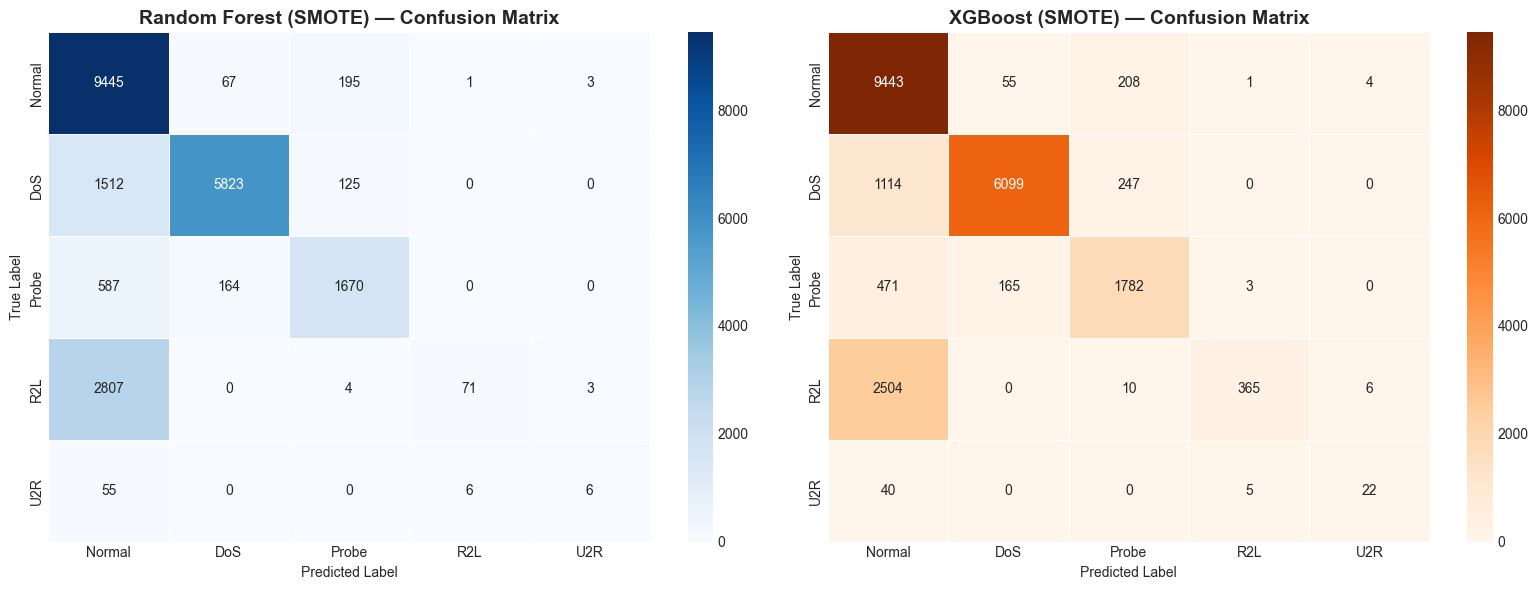

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, y_pred, cmap, title in [
    (axes[0], rf_pred,  'Blues',   'Random Forest (SMOTE)'),
    (axes[1], xgb_pred, 'Oranges', 'XGBoost (SMOTE)'),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
                ax=ax, linewidths=0.5)
    ax.set_title(f'{title} — Confusion Matrix', fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'confusion_matrices.png'), dpi=300, bbox_inches='tight')
plt.show()

## Step 9 — Model Comparison (F1 / Precision / Recall per Class)

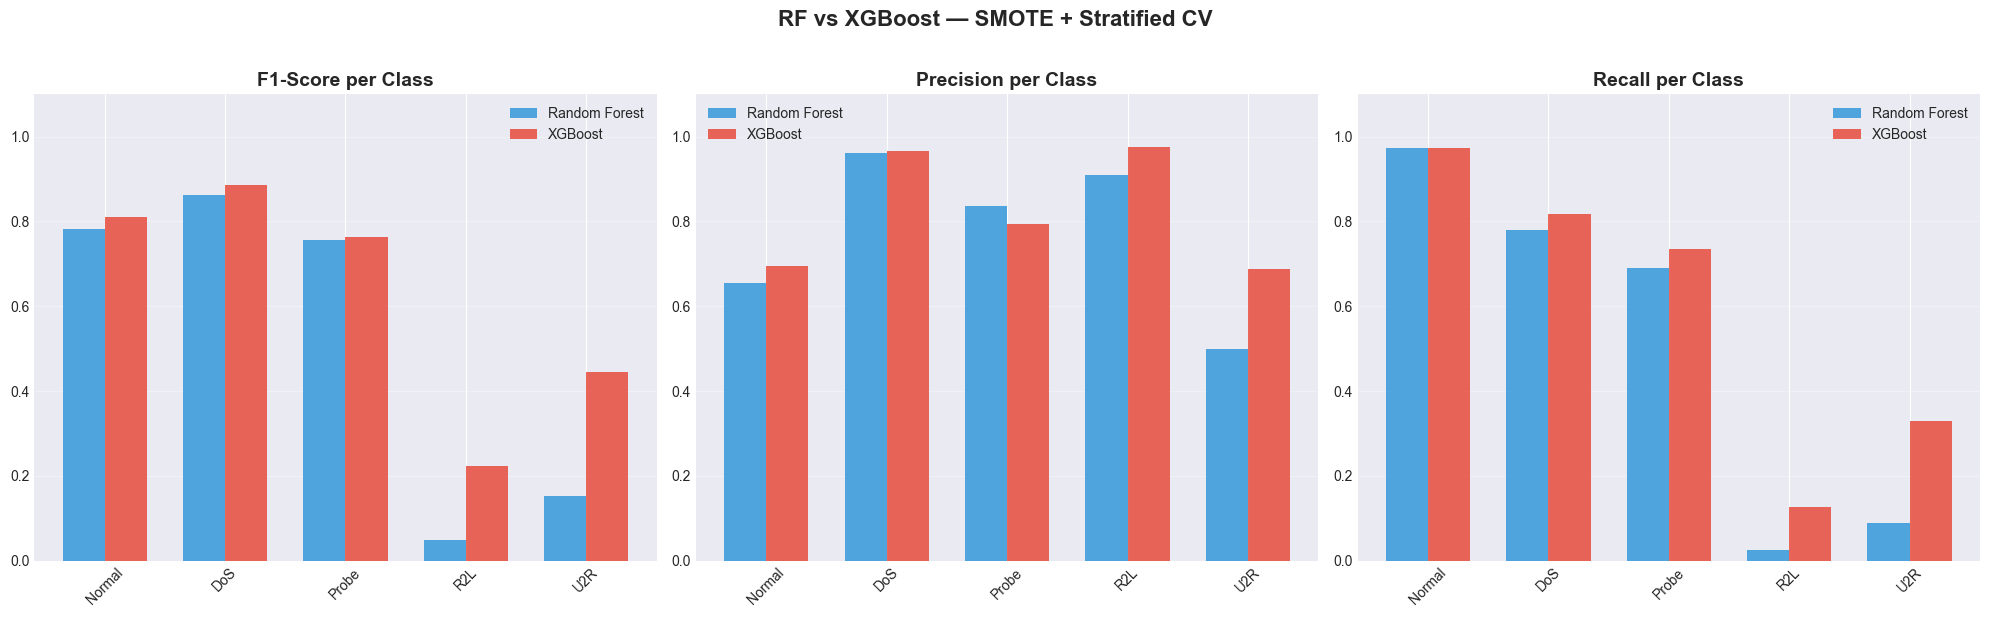

In [14]:
rf_p,  rf_r,  rf_f,  _ = precision_recall_fscore_support(y_test, rf_pred,  average=None)
xgb_p, xgb_r, xgb_f, _ = precision_recall_fscore_support(y_test, xgb_pred, average=None)

x, width = np.arange(len(CLASS_LABELS)), 0.35
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (mrf, mxgb), title in zip(axes,
        [(rf_f, xgb_f), (rf_p, xgb_p), (rf_r, xgb_r)],
        ['F1-Score', 'Precision', 'Recall']):
    ax.bar(x - width/2, mrf,  width, label='Random Forest', color='#3498db', alpha=0.85)
    ax.bar(x + width/2, mxgb, width, label='XGBoost',       color='#e74c3c', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(CLASS_LABELS, rotation=45)
    ax.set_title(f'{title} per Class', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1.1); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.suptitle('RF vs XGBoost — SMOTE + Stratified CV', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'model_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

## Step 10 — ROC Curves

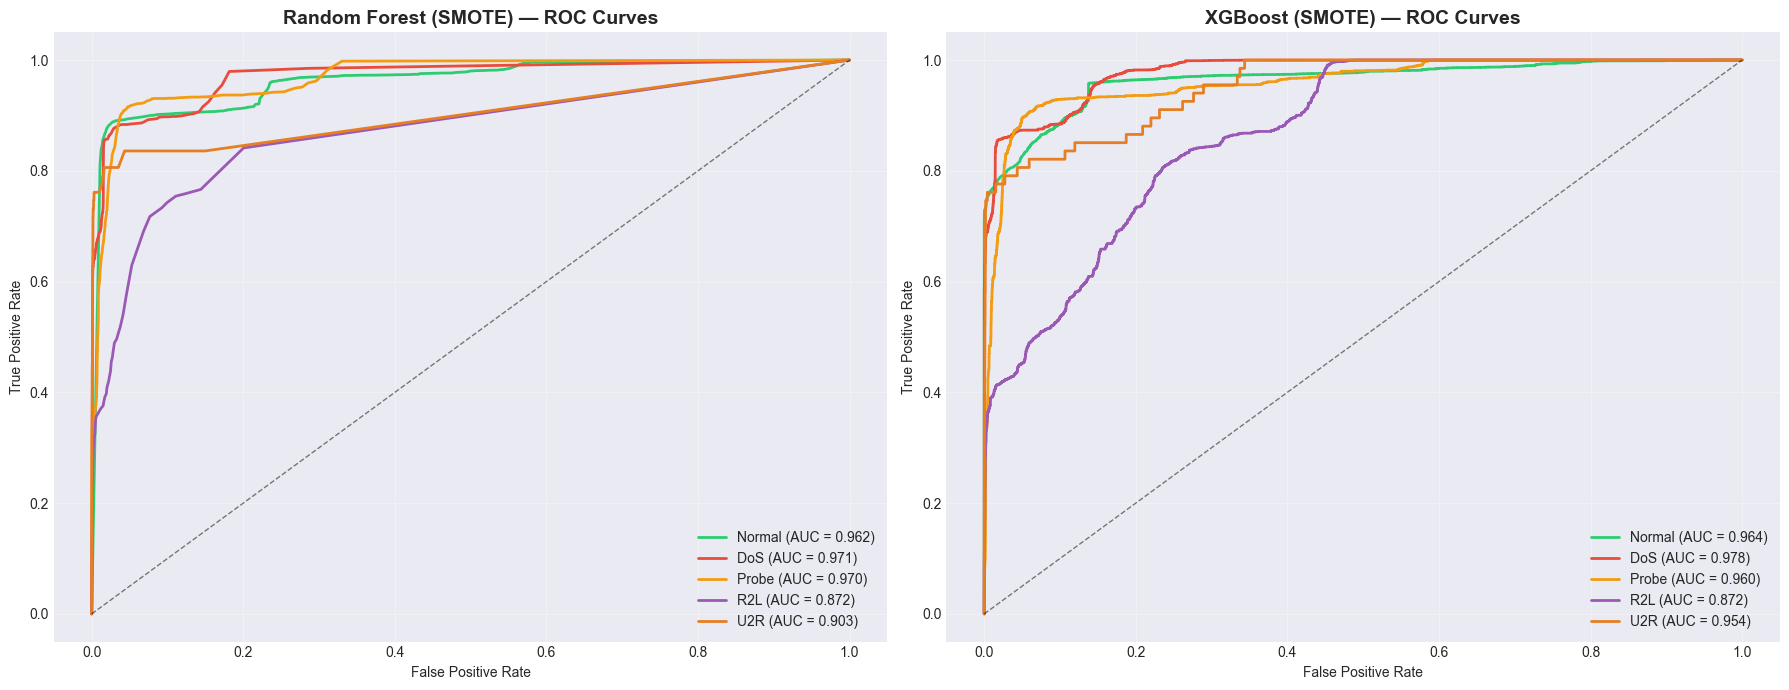

In [15]:
y_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, y_proba, title in [
    (axes[0], rf_proba,  'Random Forest (SMOTE)'),
    (axes[1], xgb_proba, 'XGBoost (SMOTE)'),
]:
    for i in range(5):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        ax.plot(fpr, tpr, color=COLORS[i], lw=2,
                label=f'{CLASS_LABELS[i]} (AUC = {auc(fpr, tpr):.3f})')
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
    ax.set_title(f'{title} — ROC Curves', fontsize=14, fontweight='bold')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'roc_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

## Step 11 — Feature Importance (Top 20 per Model)

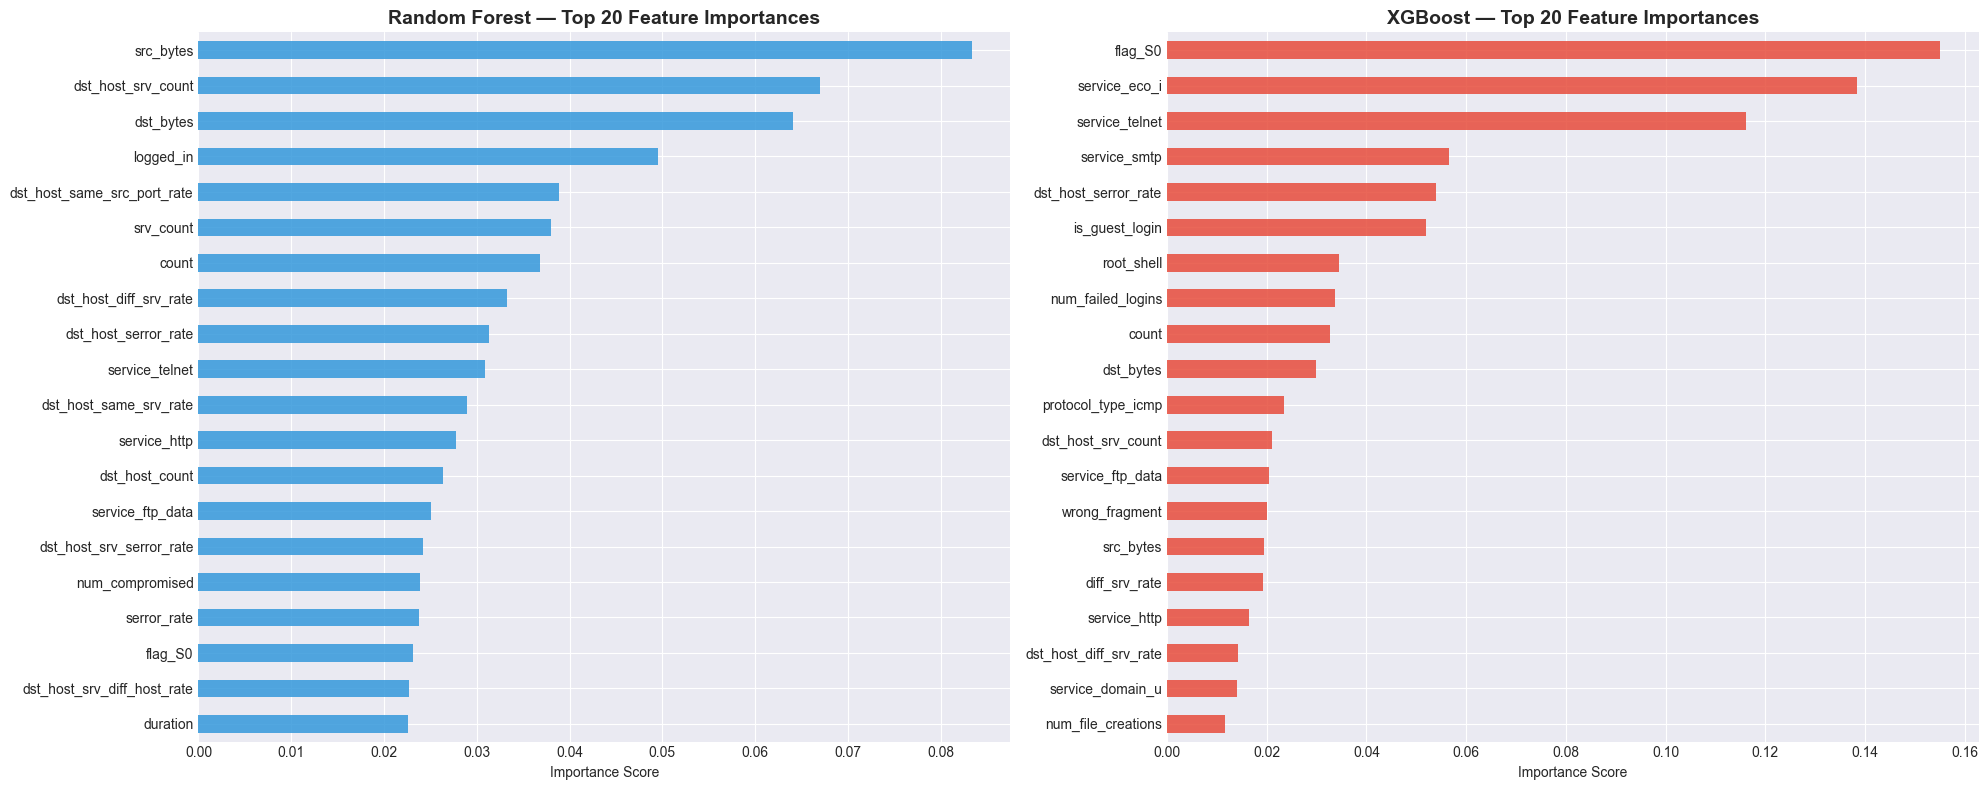


✅ All done. Start the API with:  uvicorn api.api:app --reload


In [16]:
rf_clf  = best_rf.named_steps['classifier']
xgb_clf = best_xgb.named_steps['classifier']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, clf, color, title in [
    (axes[0], rf_clf,  '#3498db', 'Random Forest'),
    (axes[1], xgb_clf, '#e74c3c', 'XGBoost'),
]:
    imp = pd.Series(clf.feature_importances_, index=X_train.columns).nlargest(20)
    imp.sort_values().plot(kind='barh', ax=ax, color=color, alpha=0.85)
    ax.set_title(f'{title} — Top 20 Feature Importances', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ All done. Start the API with:  uvicorn api.api:app --reload")